## Simple start

Quick start

In [24]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.25)

In [16]:
base_export = Path("/Users/horst/Downloads/schuham_light_stim_tif/LC_brain1__00001")

In [47]:
from scanimage_octo_reader import check_recording, read_recording

recording = read_recording(base_export.as_posix() + '.tif')  # or merge_acquisition=True
print(recording.summary())
print(recording.trigger_summary())

aux0 = recording.aux[0]["timestamp_s"]  # trigger times, seconds
report = check_recording(recording)
print(report.ok, [issue.message for issue in report.issues])

{'n_pages': 20000, 'n_files': 1, 'pages_per_file': [20000], 'image_shape': [512, 512], 'dtype': 'int16', 'bigtiff': True, 'n_channels': 1, 'channels_saved': [1], 'volumetric': True, 'n_slices': 3, 'frames_per_slice': 1, 'flyback_frames': 1, 'pages_per_volume': 4, 'n_volumes': 5000, 'zs': [4087.75, 4077.75, 4067.75], 'frame_rate_hz': 30.0115, 'volume_rate_hz': 7.50287, 'duration_s': 666.34447977, 'epoch': '2026-08-03T12:35:19.847000', 'zoom': 3, 'pixels_per_line': 512, 'lines_per_frame': 512, 'objective_resolution': 15, 'scanner_type': 'RG', 'scanner_name': 'Sutter_MOM_RG', 'bidirectional': True, 'mroi_enabled': False, 'si_version': '2022.1.0', 'sample_position': [-503.438, 4995.38, 3917.75], 'axes_position': [1933.06, 7897.5, 15475.1]}
{'aux': {'aux0': {'n_events': 67, 'n_nonfinite': 0, 'n_negative': 0, 'first_timestamp_s': 3.43918832, 'last_timestamp_s': 663.454377935, 'median_interval_s': 9.999975907500016, 'min_interval_s': 9.99996638, 'max_interval_s': 10.000584979999985}}, 'aux_li

## Loading single output files


In [17]:
frames = np.load(base_export / "frames.npy")
aux0 = np.load(base_export / "aux/aux0.npy")

print(frames["frame_timestamp_s"][:5])

[0.         0.03332115 0.06664228 0.09996336 0.1332845 ]


### Frame example

In [ ]:
print(frames["frame_timestamp_s"][:5]) # This is every plane consecutively 

[0.         0.03332115 0.06664228 0.09996336 0.1332845 ]


In [ ]:
frames['volume_timestamp_s'][:5] # This changes only for each acquired volume

array([0.       , 0.       , 0.       , 0.       , 0.1332845])

### AUX trigger example

In [9]:
print(aux0["timestamp_s"])

[  3.43918832  13.43915576  23.43973168  33.43969806  43.44027447
  53.44024228  63.44021116  73.4407895   83.44075811  93.44133548
 103.4413054  113.44188483 123.44185667 133.44182817 143.44240815
 153.44237978 163.4429589  173.44292982 183.44290043 193.44347978
 203.44345132 213.44403215 223.44400269 233.44458328 243.44455595
 253.44452944 263.44510796 273.4450795  283.44566084 293.44563452
 303.4456064  313.44618674 323.44615892 333.44673871 343.44671012
 353.44728911 363.44726021 373.44723112 383.44780966 393.44777829
 403.44835524 413.44832676 423.44890686 433.44887865 443.44885042
 453.44943119 463.44940316 473.44998234 483.44995437 493.44992897
 503.45051002 513.45048382 523.45106617 533.45104019 543.45162378
 553.45160045 563.45157768 573.45216266 583.45213833 593.45272193
 603.45269703 613.45267326 623.45325674 633.45323289 643.45381741
 653.45379436 663.45437794]


In [10]:
aux0["frame_number"]

array([  104,   404,   704,  1004,  1304,  1604,  1904,  2205,  2505,
        2805,  3105,  3405,  3705,  4005,  4306,  4606,  4906,  5206,
        5506,  5806,  6106,  6407,  6707,  7007,  7307,  7607,  7907,
        8207,  8507,  8808,  9108,  9408,  9708, 10008, 10308, 10608,
       10909, 11209, 11509, 11809, 12109, 12409, 12709, 13010, 13310,
       13610, 13910, 14210, 14510, 14810, 15111, 15411, 15711, 16011,
       16311, 16611, 16911, 17212, 17512, 17812, 18112, 18412, 18712,
       19012, 19312, 19613, 19913])

In [12]:
aux0["volume_index"]

array([  25,  100,  175,  250,  325,  400,  475,  551,  626,  701,  776,
        851,  926, 1001, 1076, 1151, 1226, 1301, 1376, 1451, 1526, 1601,
       1676, 1751, 1826, 1901, 1976, 2051, 2126, 2201, 2276, 2351, 2426,
       2501, 2576, 2651, 2727, 2802, 2877, 2952, 3027, 3102, 3177, 3252,
       3327, 3402, 3477, 3552, 3627, 3702, 3777, 3852, 3927, 4002, 4077,
       4152, 4227, 4302, 4377, 4452, 4527, 4602, 4677, 4752, 4827, 4903,
       4978])

(0.9, 1.1)

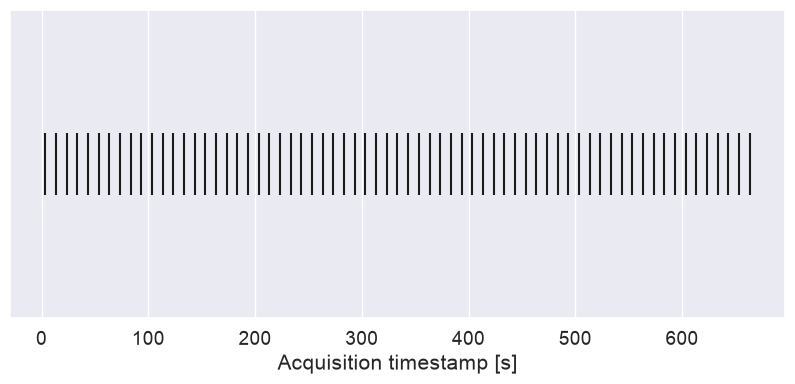

In [44]:
fig  = plt.figure(figsize=(10,4))
ax= fig.add_subplot(111)
ax.scatter(aux0["timestamp_s"], np.ones_like(aux0["timestamp_s"]), marker='|', s=2000, color='k')
ax.set_xlabel('Acquisition timestamp [s]')
ax.set_yticks([])
ax.set_ylim(.9,1.1)